# 03 · Feature engineering

**Input:** `data/interim/rdu_hourly_clean_2015-01-01_to_2026-09-16.csv` (from `02`)
**Output:** `data/interim/rdu_hourly_features.csv`, one row per hour with the building blocks for the model. `04` combines a *forecast-start* row with a *target* row into the final model matrix X.

**Rule:** every feature must be computable at the forecast start (12am Sep 17) from data before it. Calendar terms are always known, climatology uses earlier years only, and state features use past hours only.

| Section | Content |
|---|---|
| 1 | Load the cleaned table |
| 2 | Calendar features (cyclical encoding, season × hour) |
| 3 | Past-only climatology and anomaly |
| 4 | Forecast-start state features |
| 5 | Checks and export |

## 1. Load the cleaned table

In [14]:
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
CLEAN_FILE = INTERIM_DIR / "rdu_hourly_clean_2015-01-01_to_2026-09-16.csv"
FEATURES_FILE = INTERIM_DIR / "rdu_hourly_features.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

NY = ZoneInfo("America/New_York")
FORECAST_START = pd.Timestamp("2026-09-17", tz=NY)
VALIDATION_START = FORECAST_START - pd.Timedelta(days=14)


def save_fig(fig, name):
    """Save a figure to reports/figures for the slides and write-up."""
    fig.savefig(FIG_DIR / f"03_{name}.png", dpi=150, bbox_inches="tight")


clean = pd.read_csv(CLEAN_FILE, index_col="hour_utc", parse_dates=["hour_utc"], dtype={"source_era": "string"})
clean["hour_local"] = pd.to_datetime(clean["hour_local"], utc=True).dt.tz_convert(NY)

checks = {
    "continuous hourly UTC index": clean.index.is_unique
        and clean.index.to_series().diff().dropna().eq(pd.Timedelta(hours=1)).all(),
    "nothing at/after forecast start": clean.index.max() < FORECAST_START,
    "validation = last 336 hours": clean["partition"].eq("validation").sum() == 336
        and clean.index[clean["partition"].eq("validation")].min() == VALIDATION_START,
    "temperature labels as exported in 02": int(clean["temperature"].notna().sum()) == 102_462,
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), "The cleaned table is not what 02 exported - rerun 02 first."
print(f"Loaded {CLEAN_FILE.relative_to(PROJECT_ROOT)}: {clean.shape[0]:,} hours x {clean.shape[1]} columns")
print(f"First hour: {clean['hour_local'].iloc[0]:%Y-%m-%d %H:%M %Z}   Last hour: {clean['hour_local'].iloc[-1]:%Y-%m-%d %H:%M %Z}")


# Append the 336 forecast hours (12am Sep 17 - 11pm Sep 30) as empty rows: their calendar features and
# climatology are built with the same code below, while their temperature stays unknown.
forecast_hours = pd.date_range(FORECAST_START.tz_convert("UTC"), periods=336, freq="h", name="hour_utc")
clean = clean.reindex(clean.index.append(forecast_hours))
clean.loc[forecast_hours, "hour_local"] = forecast_hours.tz_convert(NY)
clean.loc[forecast_hours, "partition"] = "forecast"
clean.loc[forecast_hours, ["record_observed", "target_available"]] = False
print(f"Appended {len(forecast_hours)} forecast hours: {forecast_hours[0].tz_convert(NY):%Y-%m-%d %H:%M} -> "
      f"{forecast_hours[-1].tz_convert(NY):%Y-%m-%d %H:%M} (temperature unknown)")
print(clean["partition"].value_counts().to_string())

,passed
continuous hourly UTC index,True
nothing at/after forecast start,True
validation = last 336 hours,True
temperature labels as exported in 02,True


Loaded data/interim/rdu_hourly_clean_2015-01-01_to_2026-09-16.csv: 102,647 hours x 20 columns
First hour: 2015-01-01 00:00 EST   Last hour: 2026-09-16 23:00 EDT
Appended 336 forecast hours: 2026-09-17 00:00 -> 2026-09-30 23:00 (temperature unknown)
partition
train         102311
validation       336
forecast         336


## 2. Calendar features

Hour 23 and hour 0 are one hour apart, but as plain numbers they are 23 apart; Dec 31 and Jan 1 have the same problem. Placing each cycle on a circle (sine and cosine) fixes this and lets a linear model represent smooth cycles:

- `doy_sin1/cos1`, `doy_sin2/cos2`: position in the year (1st and 2nd harmonic, leap years handled).
- `hour_sin1/cos1`, `hour_sin2/cos2`: local hour of day. The 2nd harmonic lets the daily curve be asymmetric (about 9 hours of warming from 6am to 3pm, 15 hours of cooling).
- Season × hour products: let the daily cycle change with the season, a targeted interaction instead of a full polynomial expansion.
- `years_since_2015`: slow trend term, kept for testing in `04`.

Calendar features describe the *target* hour, which is known for any future time.

12 calendar features: ['doy_sin1', 'doy_cos1', 'hour_sin1', 'hour_cos1', 'doy_sin2', 'doy_cos2', 'hour_sin2', 'hour_cos2', 'doy_sin1_x_hour_sin1', 'doy_sin1_x_hour_cos1', 'doy_cos1_x_hour_sin1', 'doy_cos1_x_hour_cos1']


,year,day_of_year,local_hour,doy_sin1,doy_cos1,hour_sin1,hour_cos1,doy_sin2,doy_cos2,hour_sin2,hour_cos2,doy_sin1_x_hour_sin1,doy_sin1_x_hour_cos1,doy_cos1_x_hour_sin1,doy_cos1_x_hour_cos1,years_since_2015
hour_utc,,,,,,,,,,,,,,,,
2015-01-01 05:00:00+00:00,2015,1,0,0.000,1.0,0.0,1.0,0.000,1.0,0.0,1.0,0.000,0.000,0.0,1.0,0.001
2015-01-01 11:00:00+00:00,2015,1,6,0.004,1.0,1.0,0.0,0.009,1.0,0.0,-1.0,0.004,0.000,1.0,0.0,0.001
2015-01-01 17:00:00+00:00,2015,1,12,0.009,1.0,0.0,-1.0,0.017,1.0,-0.0,1.0,0.000,-0.009,0.0,-1.0,0.002
2015-01-01 23:00:00+00:00,2015,1,18,0.013,1.0,-1.0,-0.0,0.026,1.0,0.0,-1.0,-0.013,-0.000,-1.0,-0.0,0.003


Distance on the clock circle: 23h -> 0h = 0.26, 0h -> 12h = 2.00


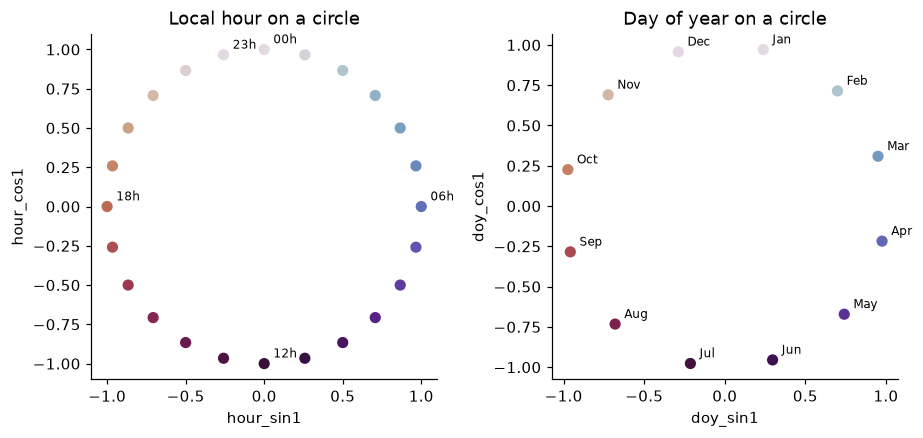

In [15]:
local = clean["hour_local"]
features = pd.DataFrame(index=clean.index)
features["year"] = local.dt.year
features["day_of_year"] = local.dt.dayofyear
features["local_hour"] = local.dt.hour

# Position in the year (0-1, continuous through the day, leap years handled) and in the day (0-1)
days_in_year = np.where(local.dt.is_leap_year, 366, 365)
year_fraction = (features["day_of_year"] - 1 + features["local_hour"] / 24) / days_in_year
day_fraction = features["local_hour"] / 24

for k in (1, 2):  # first and second harmonics
    features[f"doy_sin{k}"] = np.sin(2 * np.pi * k * year_fraction)
    features[f"doy_cos{k}"] = np.cos(2 * np.pi * k * year_fraction)
    features[f"hour_sin{k}"] = np.sin(2 * np.pi * k * day_fraction)
    features[f"hour_cos{k}"] = np.cos(2 * np.pi * k * day_fraction)

# Season x hour interactions: lets the daily cycle change shape with the season
for season in ("doy_sin1", "doy_cos1"):
    for daily in ("hour_sin1", "hour_cos1"):
        features[f"{season}_x_{daily}"] = features[season] * features[daily]

# Slow trend term (years since the start of the data), tested later in 04
features["years_since_2015"] = (clean.index - pd.Timestamp("2015-01-01", tz="UTC")) / pd.Timedelta(days=365.25)

CALENDAR_FEATURES = [c for c in features.columns if c.startswith(("doy_", "hour_"))]
print(f"{len(CALENDAR_FEATURES)} calendar features:", CALENDAR_FEATURES)
display(features.loc[features["local_hour"].isin([0, 6, 12, 18])].head(4).round(3))

# Sanity check: 23:00 and 00:00 are neighbours on the circle, Dec 31 and Jan 1 as well
hour_point = lambda h: np.array([np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24)])
print(f"Distance on the clock circle: 23h -> 0h = {np.linalg.norm(hour_point(23) - hour_point(0)):.2f}, "
      f"0h -> 12h = {np.linalg.norm(hour_point(0) - hour_point(12)):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
hours = np.arange(24)
axes[0].scatter(np.sin(2 * np.pi * hours / 24), np.cos(2 * np.pi * hours / 24), c=hours, cmap="twilight", s=40)
for h in (0, 6, 12, 18, 23):
    axes[0].annotate(f"{h:02d}h", (np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24)),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set(title="Local hour on a circle", xlabel="hour_sin1", ylabel="hour_cos1", aspect="equal")
mid_months = pd.to_datetime([f"2025-{m:02d}-15" for m in range(1, 13)])
month_fraction = (mid_months.dayofyear - 1) / 365
axes[1].scatter(np.sin(2 * np.pi * month_fraction), np.cos(2 * np.pi * month_fraction), c=range(12), cmap="twilight", s=40)
for name, f in zip(mid_months.strftime("%b"), month_fraction):
    axes[1].annotate(name, (np.sin(2 * np.pi * f), np.cos(2 * np.pi * f)), textcoords="offset points",
                     xytext=(6, 4), fontsize=8)
axes[1].set(title="Day of year on a circle", xlabel="doy_sin1", ylabel="doy_cos1", aspect="equal")
fig.tight_layout()
save_fig(fig, "cyclical_encoding")
plt.show()

### 2.1 Sanity check: how much do the calendar features explain?

A linear regression of temperature on the calendar features, fitted and scored on the training period. This is an in-sample check rather than a forecast; compare with the calendar-average table in `02`, Section 6b.

In [16]:
# How much do the calendar features alone explain? (in-sample, training period only - a sanity check, not a forecast)
train_rows = clean["partition"].eq("train") & clean["temperature"].notna()
y_train = clean.loc[train_rows, "temperature"]
feature_sets = {
    "year cycle only (doy, 2 harmonics)": [c for c in CALENDAR_FEATURES if c.startswith("doy_") and "_x_" not in c],
    "+ daily cycle (hour, 2 harmonics)": [c for c in CALENDAR_FEATURES if "_x_" not in c],
    "+ season x hour interactions": CALENDAR_FEATURES,
}
calendar_check = {}
for name, columns in feature_sets.items():
    fitted = LinearRegression().fit(features.loc[train_rows, columns], y_train).predict(features.loc[train_rows, columns])
    calendar_check[name] = {"features": len(columns), "R2": 1 - ((y_train - fitted) ** 2).sum() / ((y_train - y_train.mean()) ** 2).sum(),
                            "RMSE_deg_C": np.sqrt(((y_train - fitted) ** 2).mean())}
display(pd.DataFrame(calendar_check).T.round(3))

,features,R2,RMSE_deg_C
"year cycle only (doy, 2 harmonics)",4.0,0.622,5.740
"+ daily cycle (hour, 2 harmonics)",8.0,0.733,4.822
+ season x hour interactions,12.0,0.734,4.813


## 3. Past-only climatology and anomaly

- **Climatology** is the normal temperature for a given hour. For each year Y, a linear regression of temperature on the calendar features is fitted on years *before* Y only and then used to predict year Y: 2020 uses 2015–2019, and 2026 (including the forecast hours) uses 2015–2025. 2015 has no earlier year and gets no climatology; it only serves as training material for later years.
- **Anomaly** = observed temperature − climatology, i.e. how much warmer (+) or colder (−) than normal an hour is. This is the quantity whose memory was measured in `02`, Section 6d.

Because only earlier years are used, every value could have been computed at the time it is needed, so the backtests in `04` cannot see the future.

In [17]:
CLIMATOLOGY_FEATURES = CALENDAR_FEATURES
observed_rows = clean["temperature"].notna()

# For each year, fit temperature ~ calendar features on EARLIER years only, then predict that year
features["climatology"] = np.nan
climatology_rows = []
for year in range(features["year"].min() + 1, features["year"].max() + 1):
    fit_rows = observed_rows & features["year"].lt(year)
    model = LinearRegression().fit(features.loc[fit_rows, CLIMATOLOGY_FEATURES], clean.loc[fit_rows, "temperature"])
    year_rows = features["year"].eq(year)
    features.loc[year_rows, "climatology"] = model.predict(features.loc[year_rows, CLIMATOLOGY_FEATURES])
    climatology_rows.append({"year": year, "fitted_on": f"{features['year'].min()}-{year - 1}",
                             "training_hours": int(fit_rows.sum())})

features["anomaly"] = clean["temperature"] - features["climatology"]
climatology_summary = pd.DataFrame(climatology_rows).set_index("year")
climatology_summary["mean_anomaly"] = features.groupby("year")["anomaly"].mean().round(2)
climatology_summary["anomaly_std"] = features.groupby("year")["anomaly"].std().round(2)
display(climatology_summary)

print(f"Climatology available for {features['climatology'].notna().sum():,} of {len(features):,} hours "
      f"(missing = year {features['year'].min()}, which has no earlier year)")
print(f"Anomaly available for {features['anomaly'].notna().sum():,} hours")

,fitted_on,training_hours,mean_anomaly,anomaly_std
year,,,,
2016,2015-2015,8760,0.26,4.98
2017,2015-2016,17541,0.32,5.08
2018,2015-2017,26298,-0.54,5.10
2019,2015-2018,35055,0.18,4.57
2020,2015-2019,43813,0.21,4.84
2021,2015-2020,52597,-0.16,4.50
2022,2015-2021,61353,0.20,4.86
2023,2015-2022,70113,0.91,4.63
2024,2015-2023,78873,1.14,4.33


Climatology available for 94,223 of 102,983 hours (missing = year 2015, which has no earlier year)
Anomaly available for 93,702 hours


### 3.1 Example: September 2025

Observed temperature, the climatology fitted on 2015–2024, and their difference (the anomaly).

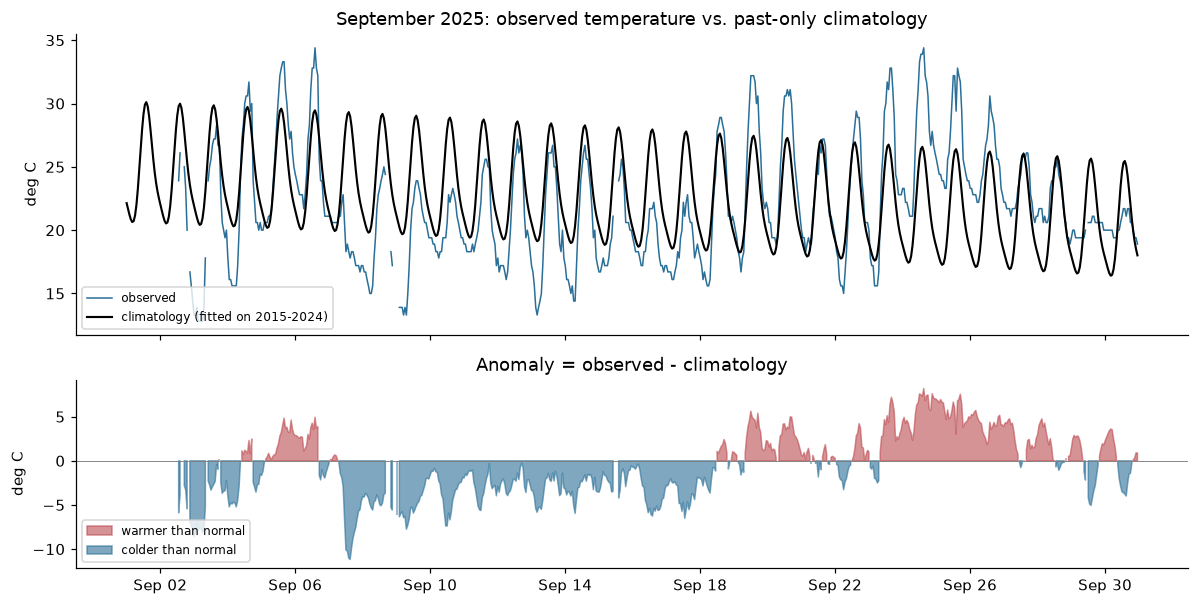

In [18]:
import matplotlib.dates as mdates

example = (clean["hour_local"] >= pd.Timestamp("2025-09-01", tz=NY)) & (clean["hour_local"] < pd.Timestamp("2025-10-01", tz=NY))
example_local = clean.loc[example, "hour_local"]

fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})
axes[0].plot(example_local, clean.loc[example, "temperature"], color="#2a6f97", linewidth=1, label="observed")
axes[0].plot(example_local, features.loc[example, "climatology"], color="black", linewidth=1.4,
             label="climatology (fitted on 2015-2024)")
axes[0].set(title="September 2025: observed temperature vs. past-only climatology", ylabel="deg C")
axes[0].legend(fontsize=8, loc="lower left")
example_anomaly = features.loc[example, "anomaly"]
axes[1].fill_between(example_local, example_anomaly, 0, where=example_anomaly > 0, color="#bc4b51", alpha=0.6,
                     label="warmer than normal")
axes[1].fill_between(example_local, example_anomaly, 0, where=example_anomaly < 0, color="#2a6f97", alpha=0.6,
                     label="colder than normal")
axes[1].axhline(0, color="grey", linewidth=0.6)
axes[1].set(title="Anomaly = observed - climatology", ylabel="deg C")
axes[1].legend(fontsize=8, loc="lower left")
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=4, tz=NY))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=NY))
fig.tight_layout()
save_fig(fig, "climatology_and_anomaly")
plt.show()

## 4. Forecast-start state features

What the weather looks like at the moment a forecast is issued. Each value at hour *t* uses only hours ≤ *t* (trailing windows on the complete hourly grid):

| Feature | Meaning |
|---|---|
| `anom_now` | anomaly at that hour (gaps of up to 3 h bridged with the last value) |
| `anom_24h`, `anom_7d`, `anom_30d` | mean anomaly over the last 24 hours / 7 days / 30 days (at least 75% of the hours present) |
| `dewpoint_depression` | temperature − dew point (dry vs. humid air) |
| `pressure_change_24h` | altimeter change over the last 24 hours (falling pressure often comes before a front) |
| `cloud_cover_octas` | total cloud cover |

**Convention for `04`:** a forecast is issued from the 11pm row of the evening before (for the real task: Sep 16, 2026, 11pm), and lead 1 is the next hour (12am). Training origins are the 11pm rows of July–November, 2016–2025, so that every 14-day target window stays within the same year and its past-only climatology. The 336 forecast rows only serve as targets, so their state is left empty.

In [19]:
# State at hour t, using only hours <= t (trailing windows on the complete hourly grid)
ANOMALY_WINDOWS = {"anom_24h": 24, "anom_7d": 24 * 7, "anom_30d": 24 * 30}
state = pd.DataFrame(index=features.index)
state["anom_now"] = features["anomaly"].ffill(limit=3)  # bridge gaps of up to 3 h with the last value
for name, hours in ANOMALY_WINDOWS.items():
    state[name] = features["anomaly"].rolling(hours, min_periods=int(0.75 * hours)).mean()
state["dewpoint_depression"] = (clean["temperature"] - clean["dew_point_temperature"]).ffill(limit=3)
state["pressure_change_24h"] = clean["altimeter"].ffill(limit=3).diff(24)
state["cloud_cover_octas"] = clean["cloud_cover_octas"].ffill(limit=3)
state.loc[clean["partition"].eq("forecast")] = np.nan  # future hours are never forecast starts

STATE_FEATURES = list(state.columns)
features[STATE_FEATURES] = state

# Forecast starts used for training in 04: 11pm local (the last hour before a new day), Jul-Nov, 2016-2025
FIRST_TARGET = FORECAST_START                       # 12am Sep 17 = first forecast hour (lead 1)
ORIGIN_HOUR = (FIRST_TARGET - pd.Timedelta(hours=1)).hour  # 23 -> the forecast is issued from the 11pm row
candidate_origins = (
    features["local_hour"].eq(ORIGIN_HOUR)
    & clean["hour_local"].dt.month.between(7, 11)
    & features["year"].between(2016, 2025)
)
state_summary = features.loc[candidate_origins, STATE_FEATURES].describe().T[["count", "mean", "std", "min", "max"]]
state_summary["missing"] = int(candidate_origins.sum()) - state_summary["count"].astype(int)
display(state_summary.round(2))
print(f"Candidate training origins (11pm, Jul-Nov, 2016-2025): {int(candidate_origins.sum()):,}")

# The state on the evening before the real forecast (Sep 16, 2026, 11pm)
real_origin = clean.index[clean["hour_local"].eq(FIRST_TARGET - pd.Timedelta(hours=1))][0]
print(f"\nState at the real forecast start ({clean.at[real_origin, 'hour_local']:%Y-%m-%d %H:%M %Z}):")
display(features.loc[[real_origin], ["climatology", "anomaly"] + STATE_FEATURES]
        .assign(temperature=clean.at[real_origin, "temperature"]).T.round(2))

,count,mean,std,min,max,missing
anom_now,1526.0,-0.05,3.80,-12.65,11.63,4
anom_24h,1526.0,-0.02,3.27,-12.09,10.68,4
anom_7d,1523.0,0.00,2.27,-6.42,6.86,7
anom_30d,1530.0,0.07,1.35,-3.14,3.23,0
dewpoint_depression,1526.0,3.23,2.44,0.00,21.70,4
pressure_change_24h,1525.0,0.01,4.38,-19.60,25.40,5
cloud_cover_octas,1517.0,4.65,2.93,0.00,8.00,13


Candidate training origins (11pm, Jul-Nov, 2016-2025): 1,530

State at the real forecast start (2026-09-16 23:00 EDT):


hour_utc,2026-09-17 03:00:00+00:00
climatology,20.34
anomaly,0.76
anom_now,0.76
anom_24h,0.54
anom_7d,2.80
anom_30d,1.65
dewpoint_depression,3.90
pressure_change_24h,0.00
cloud_cover_octas,0.00
temperature,21.10


### 4.1 Do the state features carry information about the future?

For every training origin, each state feature is correlated with the anomaly *h* hours later (h = 1 … 336). A useful feature shows a clearly non-zero correlation, at least for the first leads. This is the idea of `02`, Section 6d, applied to the actual features.

,1 hour,1 day,3 days,7 days,14 days
anom_now,0.98,0.56,0.20,0.06,0.05
anom_24h,0.84,0.48,0.23,0.04,0.04
anom_7d,0.47,0.30,0.14,0.05,0.03
anom_30d,0.25,0.18,0.10,0.04,0.03
dewpoint_depression,-0.02,-0.13,0.00,-0.00,0.02
pressure_change_24h,-0.40,-0.15,0.05,-0.01,-0.04
cloud_cover_octas,0.28,0.05,-0.07,0.00,0.02


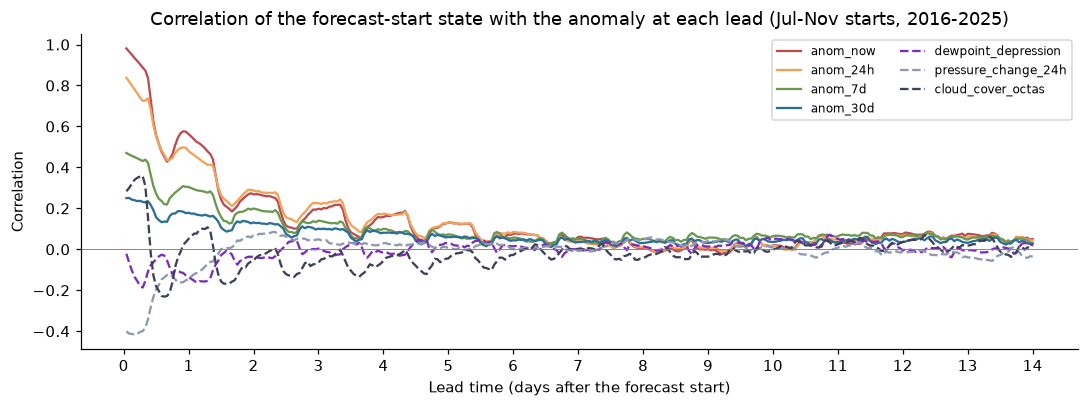

In [20]:
LEADS = np.arange(1, 14 * 24 + 1)
relevance_rows = []
for lead in LEADS:
    future_anomaly = features["anomaly"].shift(-lead)[candidate_origins]
    relevance_rows.append([features.loc[candidate_origins, f].corr(future_anomaly) for f in STATE_FEATURES])
relevance = pd.DataFrame(relevance_rows, index=pd.Index(LEADS, name="lead_hours"), columns=STATE_FEATURES)

checkpoints = {"1 hour": 1, "1 day": 24, "3 days": 72, "7 days": 168, "14 days": 336}
display(relevance.loc[list(checkpoints.values())].set_axis(list(checkpoints), axis=0).round(2).T)

fig, ax = plt.subplots(figsize=(10, 3.8))
colors = ["#bc4b51", "#f4a259", "#6a994e", "#2a6f97", "#7b2cbf", "#8d99ae", "#3d405b"]
for feature, color in zip(STATE_FEATURES, colors):
    ax.plot(LEADS / 24, relevance[feature], color=color, linewidth=1.5,
            linestyle="-" if feature.startswith("anom") else "--", label=feature)
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="Correlation of the forecast-start state with the anomaly at each lead (Jul-Nov starts, 2016-2025)",
       xlabel="Lead time (days after the forecast start)", ylabel="Correlation")
ax.set_xticks(range(15))
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
save_fig(fig, "state_feature_relevance")
plt.show()

## 5. Checks and export

Final checks, then `data/interim/rdu_hourly_features.csv` (one row per hour, including the 336 empty forecast hours). The file is read back and compared with the in-memory table.

| Column group | Columns |
|---|---|
| bookkeeping | `hour_utc` (index), `hour_local`, `partition` (`train` / `validation` / `forecast`) |
| target | `temperature` (empty for forecast hours) |
| calendar | `year`, `day_of_year`, `local_hour`, 12 sin/cos and season × hour terms, `years_since_2015` |
| climatology | `climatology` (past-only normal), `anomaly` (temperature − climatology) |
| state | `anom_now`, `anom_24h`, `anom_7d`, `anom_30d`, `dewpoint_depression`, `pressure_change_24h`, `cloud_cover_octas` |

`04` builds the model matrix X from this table: state features from the forecast-start row, calendar features and climatology from the target row, plus the lead time.

In [21]:
# Guard: `features` must have been rebuilt after the forecast hours were appended in Cell 2
assert features.index.equals(clean.index), (
    f"features has {len(features):,} rows but clean has {len(clean):,} - restart the kernel and run all cells"
)

EXPORT_COLUMNS = (
    ["hour_local", "partition", "temperature", "year", "day_of_year", "local_hour"]
    + CALENDAR_FEATURES + ["years_since_2015", "climatology", "anomaly"] + STATE_FEATURES
)
export = features.join(clean[["hour_local", "partition", "temperature"]])[EXPORT_COLUMNS]

final_checks = {
    "one row per hour, incl. 336 forecast hours": export.index.is_unique and export["partition"].eq("forecast").sum() == 336,
    "calendar features complete": export[CALENDAR_FEATURES].notna().all().all(),
    "climatology for every hour from 2016 on": export.loc[export["year"].ge(2016), "climatology"].notna().all(),
    "forecast hours have no temperature or state": export.loc[export["partition"].eq("forecast"),
                                                              ["temperature", "anomaly", *STATE_FEATURES]].isna().all().all(),
    "real forecast start has a full state": export.loc[real_origin, STATE_FEATURES].notna().all(),
}
display(pd.Series(final_checks, name="passed").to_frame())
failed = [name for name, passed in final_checks.items() if not passed]
assert not failed, f"Final checks failed: {failed} - restart the kernel and run all cells"

export.round(5).to_csv(FEATURES_FILE, index_label="hour_utc")
reloaded = pd.read_csv(FEATURES_FILE, index_col="hour_utc", parse_dates=["hour_utc"])
assert reloaded.index.equals(export.index) and list(reloaded.columns) == EXPORT_COLUMNS
assert np.allclose(reloaded["climatology"], export["climatology"], atol=1e-4, equal_nan=True)
print(f"Saved {FEATURES_FILE.relative_to(PROJECT_ROOT)}: {reloaded.shape[0]:,} rows x {reloaded.shape[1]} columns "
      f"({FEATURES_FILE.stat().st_size / 1024 ** 2:.1f} MB)")
print(f"Feature groups -> calendar: {len(CALENDAR_FEATURES)}, climatology: 1, state: {len(STATE_FEATURES)}")

,passed
"one row per hour, incl. 336 forecast hours",True
calendar features complete,True
climatology for every hour from 2016 on,True
forecast hours have no temperature or state,True
real forecast start has a full state,True


/var/folders/1z/2s4dtll57g114ycx1gnkc8vc0000gn/T/ipykernel_65206/4204233524.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  export.round(5).to_csv(FEATURES_FILE, index_label="hour_utc")


Saved data/interim/rdu_hourly_features.csv: 102,983 rows x 28 columns (22.9 MB)
Feature groups -> calendar: 12, climatology: 1, state: 7
